# Predictive Modeling of Yelp Restaurant Ratings

Ranking restaurateurs may prioritize achieving a high rating threshold (4+ stars) rather than predicting exact ratings. This analysis uses business features (e.g., wheelchair accessibility, payment methods, pet policies, outdoor seating) as predictors and evaluates which models best balance capturing true positives (correctly identifying high-rated restaurants) against false positives (incorrectly recommending poorly-rated ones).

## Project Overview

This project develops and compares multiple machine learning models to predict Yelp restaurant ratings in Las Vegas. The analysis progresses from regression models (predicting exact star ratings 1-5) to classification models (predicting whether a restaurant achieves 4+ stars). The project employs techniques including linear regression, decision trees, logistic regression, and classification trees, with comprehensive model evaluation using metrics like accuracy, TPR, FPR, and OSR2. The ultimate goal is to identify actionable insights that help restaurants improve their Yelp ratings through transparent business practices and customer engagement strategies.

In [2]:
import pandas as pd
import numpy as np

In [3]:
train_data = pd.read_csv('yelp_train.csv')
test_data = pd.read_csv('yelp_test.csv')

In [4]:
print(train_data.isna().sum())
print("")
print(test_data.isna().sum())


stars                         0
review_count                  0
GoodForKids                   0
Alcohol                       0
BusinessAcceptsCreditCards    0
WiFi                          0
BikeParking                   0
ByAppointmentOnly             0
WheelechairAccessible         0
OutdoorSeating                0
RestaurantsReservations       0
DogsAllowed                   0
Caters                        0
dtype: int64

stars                         0
review_count                  0
GoodForKids                   0
Alcohol                       0
BusinessAcceptsCreditCards    0
WiFi                          0
BikeParking                   0
ByAppointmentOnly             0
WheelechairAccessible         0
OutdoorSeating                0
RestaurantsReservations       0
DogsAllowed                   0
Caters                        0
dtype: int64


## a) Handling Missing Values in Categorical Features

The dataset contains missing entries across multiple categorical business features. Rather than discarding or imputing missing values, we treat "Missing" as an explicit category in our models. This approach preserves all data and allows the model to learn patterns associated with missing information.

Treating “Missing” as its own category is a reasonable approach for categorical features because it lets us keep all the data instead of dropping or guessing values. Models like decision trees can naturally handle missing values as a separate branch, which means they can still pick up useful patterns related to why data might be missing. However, if the missing values occur randomly and don’t carry any real meaning, this approach could introduce noise and make the model harder to interpret.

## b) Building Regression Models for Star Rating Prediction

We develop regression models to predict exact Yelp star ratings (continuous values 1-5) using all available business features from the training dataset. We compare linear regression and decision tree approaches to understand the relationship between business attributes and customer ratings.

Data preparation 

Dummy variables

In [5]:
categorical_cols= ['GoodForKids', 'Alcohol', 'BusinessAcceptsCreditCards', 'WiFi', 'BikeParking', 'ByAppointmentOnly', 'WheelechairAccessible',
'OutdoorSeating', 'RestaurantsReservations', 'DogsAllowed', 'Caters']


train_encoded = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_data, columns=categorical_cols, drop_first=True)
train_encoded, test_encoded = train_encoded.align(test_encoded, join="left", axis=1, fill_value=0)

train_encoded = train_encoded.astype(int)
test_encoded = test_encoded.astype(int)

In [6]:
train_encoded

,stars,review_count,GoodForKids_FALSE,GoodForKids_TRUE,Alcohol_'full_bar',Alcohol_'none',Alcohol_(Missing),BusinessAcceptsCreditCards_FALSE,BusinessAcceptsCreditCards_TRUE,WiFi_'no',...,WheelechairAccessible_FALSE,WheelechairAccessible_TRUE,OutdoorSeating_FALSE,OutdoorSeating_TRUE,RestaurantsReservations_FALSE,RestaurantsReservations_TRUE,DogsAllowed_FALSE,DogsAllowed_TRUE,Caters_FALSE,Caters_TRUE
0,4,10,0,0,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,0
1,2,21,0,0,0,0,1,0,1,1,...,0,0,1,0,0,0,0,0,1,0
2,4,10,0,0,0,1,0,0,1,1,...,0,1,1,0,0,0,1,0,1,0
3,4,290,0,1,0,0,0,0,1,0,...,0,0,0,1,1,0,1,0,1,0
4,3,21,0,1,0,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6267,4,15,0,1,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
6268,4,395,0,1,1,0,0,0,1,0,...,0,1,0,1,0,1,0,1,1,0
6269,4,11,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6270,2,9,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0


Linear regression Model

In [7]:
import statsmodels.api as sm

X_train = train_encoded.drop(columns=["stars"])
y_train = train_encoded["stars"]


X_test = test_encoded.drop(columns=["stars"])
X_test = sm.add_constant(X_test)

y_test = test_encoded["stars"]

X_train = sm.add_constant(X_train)

linear_model = sm.OLS(y_train, X_train).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     45.77
Date:                Thu, 30 Oct 2025   Prob (F-statistic):          3.88e-206
Time:                        00:50:11   Log-Likelihood:                -7538.5
No. Observations:                6272   AIC:                         1.513e+04
Df Residuals:                    6246   BIC:                         1.530e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### b-ii) Decision Tree Regression with Complexity Tuning

We construct a regression tree using cost-complexity pruning to select the optimal tree depth. Using 5-fold cross-validation, we evaluate mean squared error (MSE) across a range of complexity parameters (ccp_alpha values), selecting the alpha that minimizes prediction error on validation data. This balances model complexity against generalization performance.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score


y_train_tree = train_encoded["stars"]
X_train_tree = train_encoded.drop(columns=["stars"])
y_test_tree = test_encoded["stars"]
X_test_tree = test_encoded.drop(columns=["stars"])

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

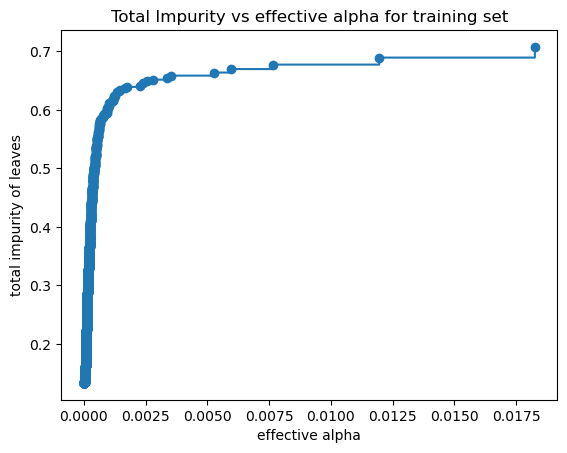

In [9]:
import matplotlib.pyplot as plt

# cost_complexity_pruning_path method returns possible ccp_alpha values that control 
# how aggressively the tree is pruned, larger alpha leads to more pruning).
tree = DecisionTreeRegressor(random_state=88)
path = tree.cost_complexity_pruning_path(X_train_tree, y_train_tree)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


fig, ax = plt.subplots()

ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")




Best alpha: 0.001742901899397964


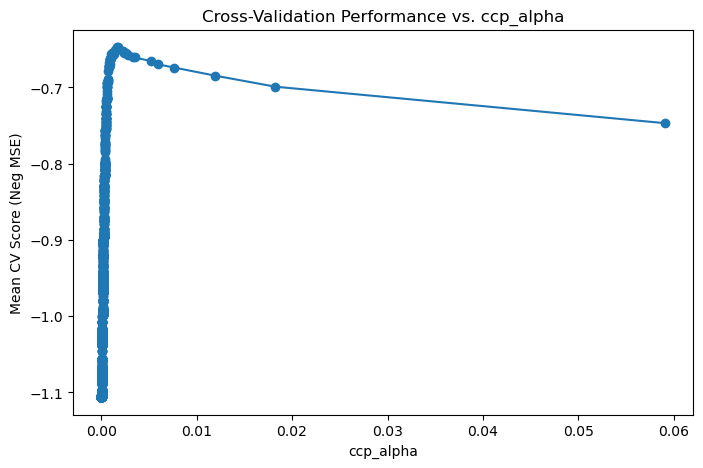

DecisionTreeRegressor(ccp_alpha=np.float64(0.001742901899397964),
                      random_state=88)

In [12]:
ccp_alphas = np.maximum(path.ccp_alphas, 0)

cv_scores = [] 
for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=88, ccp_alpha=alpha)
    scores = cross_val_score(model, X_train_tree, y_train_tree, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

#  alpha with the best CV performance, less negative value means lower MSE
best_alpha = ccp_alphas[np.argmax(cv_scores)]
print("Best alpha:", best_alpha)

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, cv_scores, marker='o', linestyle='-')
plt.xlabel("ccp_alpha")
plt.ylabel("Mean CV Score (Neg MSE)")
plt.title("Cross-Validation Performance vs. ccp_alpha")
plt.show()

best_tree = DecisionTreeRegressor(random_state=88, ccp_alpha=best_alpha)
best_tree.fit(X_train_tree, y_train_tree)

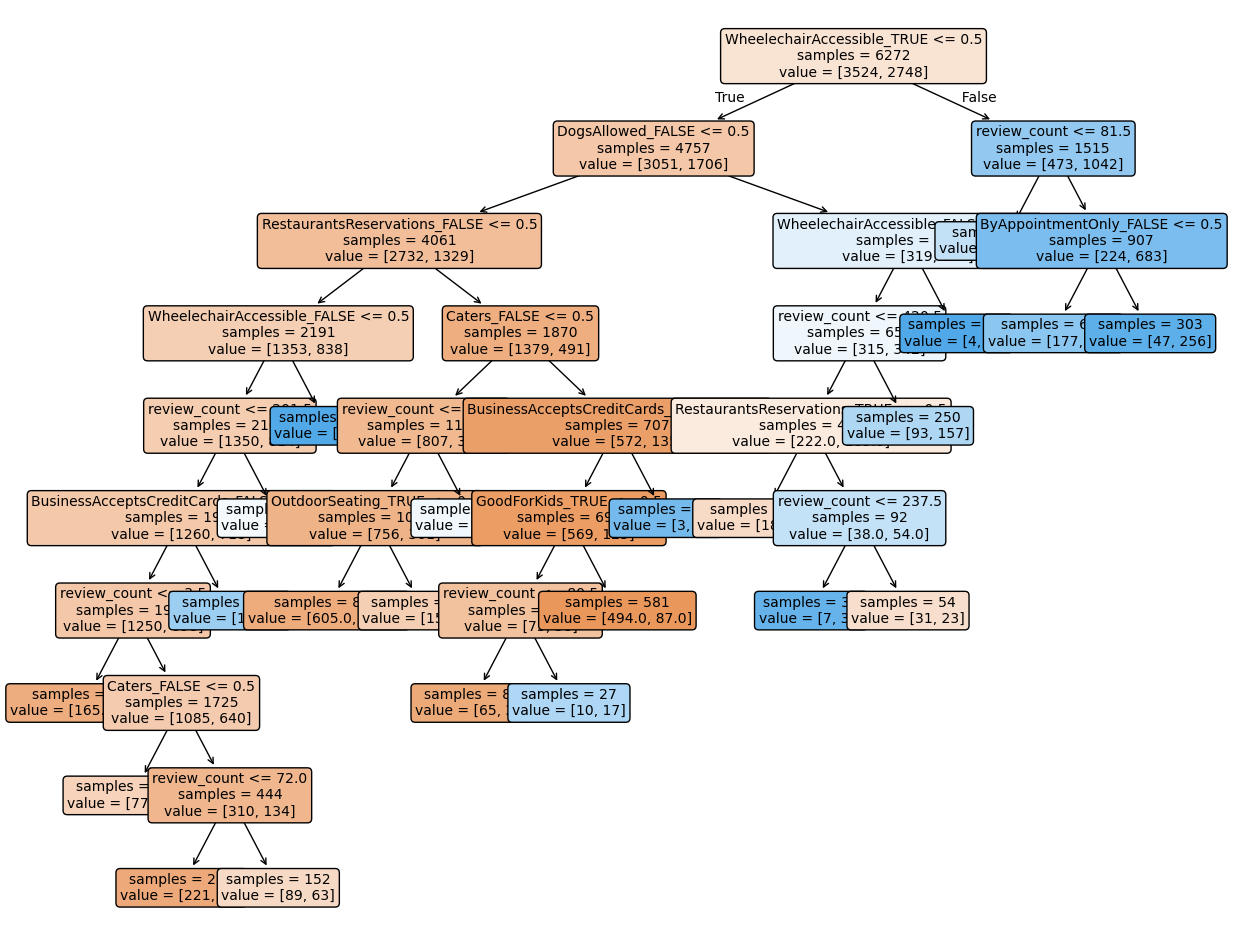

In [57]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))  # adjust size as you like
plot_tree(
    best_tree,                                 
    feature_names=X_train_tree.columns,           
    filled=True,                            
    rounded=True,                          
    fontsize=10,                              
    impurity=False                            
)
plt.show()


ii) 
I did 5 fold Cross-validation using a range of ccp_alpha values from the cost-complexity pruning path. For each alpha, I trained a decision tree and evaluated its 5-fold cross-validation score. I used neg_mean_squared_error as the scoring metric because the goal was to evaluate how well the regression tree predicts continuous Yelp ratings. The alpha with the least negative score (lowest MSE) was selected as the optimal complexity parameter. The alpha I chose from testing is Best alpha: 0.001743




In [14]:
def OSR2(model, X_test, y_test, y_train):

    y_pred = model.predict(X_test)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(y_train))**2)

    return (1 - SSE/SST)

### b-iii) Regression Model Comparison: Linear vs. Tree-Based

We evaluate both models on the test set using out-of-sample R² (OSR²) and mean absolute error (MAE). These metrics reveal how well each model generalizes to unseen data and the typical magnitude of prediction errors.

In [15]:

osr2 = OSR2(linear_model, X_test, y_test, y_train)
print("OSR2 of Linear Regression model:", osr2)

osr2_tree_regres = OSR2(best_tree, X_test_tree, y_test_tree, y_train_tree)
print("OSR2 of Decision Tree Regression model:", osr2_tree_regres)


from sklearn.metrics import mean_absolute_error

y_pred= linear_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Linear Regression MAE:", mae)


y_pred_tree = best_tree.predict(X_test_tree)

mae_tree = mean_absolute_error(y_test_tree, y_pred_tree)
print("Decision Tree MAE:", mae_tree)

OSR2 of Linear Regression model: 0.14659677038891528
OSR2 of Decision Tree Regression model: 0.12469848814039297
Linear Regression MAE: 0.6471675936649236
Decision Tree MAE: 0.6728588937473958


iii) The linear regression model performs slightly better with an MAE of 0.647 compared to 0.67 of yhr decision tree as a lower MAE means better performance.

The linear regression model also generalizes slightly better than the decision tree with OSR^2 of 0.147, higher than the OSR^2 of decision tree at 0.124. This tells us that the relationship between business features and Yelp ratings is mostly linear or additive rather than rule-based

However, both models show relatively low OSR2 values, showing that while they capture some trends, they do not explain much of the overall variation in restaurant ratings.

## c) Shifting to Classification: High-Performing vs. Below-Threshold Restaurants

Predicting exact star ratings may not align with restaurant business objectives. More practically, restaurants care about achieving a 4+ star rating threshold, which signals strong customer satisfaction and competitive advantage. We reformulate this as a binary classification problem: predicting whether a restaurant achieves 4+ stars (high-performing) or falls below that threshold.

Construct a new variable in your training and test datasets called fourOrAbove. This
variable should be equal to 1 if stars is greater than or equal to 4 and equal to 0
otherwise.

In [16]:
train_encoded["fourOrAbove"] = (train_encoded["stars"] >= 4).astype(int)
test_encoded["fourOrAbove"] = (test_encoded["stars"] >= 4).astype(int)



### d-i) Choice of Performance Metric: Accuracy

We use accuracy as the primary metric, treating false positives and false negatives with equal importance. This is reasonable for Yelp recommendations if incorrectly promoting a low-rated restaurant carries comparable risk to missing a genuine high-performer.

Using accuracy as the main metric is reasonable only if the two types of mistakes—predicting a business as 4 stars or above when it’s not (false positive) and predicting it as below 4 when it’s actually above (false negative)carry similar consequences.

In this Yelp setting, if misclassifying a low-rated business as high-rated has a higher cost, like misleading users, then accuracy alone would be misleading. In that case, metrics like precision, recall, or F1-score would be more informative.

### d-ii) Converting Regression Predictions to Classifications

We leverage our previously trained regression models by applying a threshold at 4.0 stars. Predicted ratings ≥ 4 are classified as high-performing (1), while predictions < 4 are classified as below-threshold (0). This simple approach allows direct comparison between regression-based and purpose-built classification models.

In [19]:

# if predicted rating is 4 or above, classify as 1 as positive class, else 0 as the negative class
y_pred_linear_class = (y_pred >= 4).astype(int)
y_pred_tree_class = (y_pred_tree >= 4).astype(int)



### d-iii) Logistic Regression for Classification

We build a logistic regression model using all business features to predict the probability of a restaurant achieving 4+ stars. Logistic regression provides interpretable probability estimates and coefficient insights into which features most strongly drive high ratings.

In [24]:
from sklearn.linear_model import LogisticRegression


X_train_log = train_encoded.drop(columns=["stars", "fourOrAbove"])
y_train_log = train_encoded["fourOrAbove"]

X_test_log = test_encoded.drop(columns=["stars", "fourOrAbove"])
y_test_log = test_encoded["fourOrAbove"]    

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train_log)


#since we weight FN and FP equally, our threshold is 0.5
#thresholding by sckit-learn 
y_pred_log = log_model.predict(X_test_log)
y_pred_log



array([0, 1, 1, ..., 1, 1, 1])

### d-iv) Classification Tree with Cross-Validation Tuning

We build a classification tree using the CART algorithm, tuning its complexity via 5-fold cross-validation on accuracy. The optimal ccp_alpha is selected to maximize validation accuracy, balancing interpretability with generalization performance.

classification tree model

In [25]:

from sklearn.tree import DecisionTreeClassifier


X_train_class = train_encoded.drop(columns=["stars", "fourOrAbove"])
y_train_class= train_encoded["fourOrAbove"]

X_test_class = test_encoded.drop(columns=["stars", "fourOrAbove"])
y_test_class = test_encoded["fourOrAbove"]


tree = DecisionTreeClassifier(random_state=88)
path = tree.cost_complexity_pruning_path(X_train_class, y_train_class)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

cv_scores_c = [] 
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=88, ccp_alpha=alpha)
    scores = cross_val_score(model, X_train_class, y_train_class, cv=5, scoring='accuracy')
    cv_scores_c.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(cv_scores_c)]
print("Best alpha:", best_alpha)


Best alpha: 0.0008515937738045702


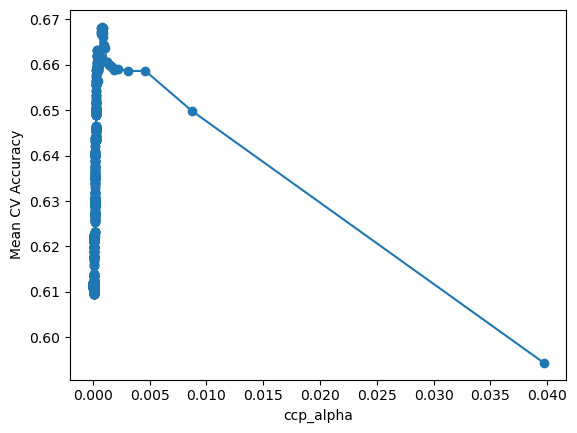

DecisionTreeClassifier(ccp_alpha=np.float64(0.0008515937738045702),
                       min_samples_split=10, random_state=88)

In [28]:

plt.plot(ccp_alphas, cv_scores_c, marker='o', linestyle='-')
plt.xlabel("ccp_alpha")
plt.ylabel("Mean CV Accuracy")
plt.show()

best_class_tree = DecisionTreeClassifier(random_state=88, ccp_alpha=best_alpha, min_samples_split=10)
best_class_tree.fit(X_train_class, y_train_class)

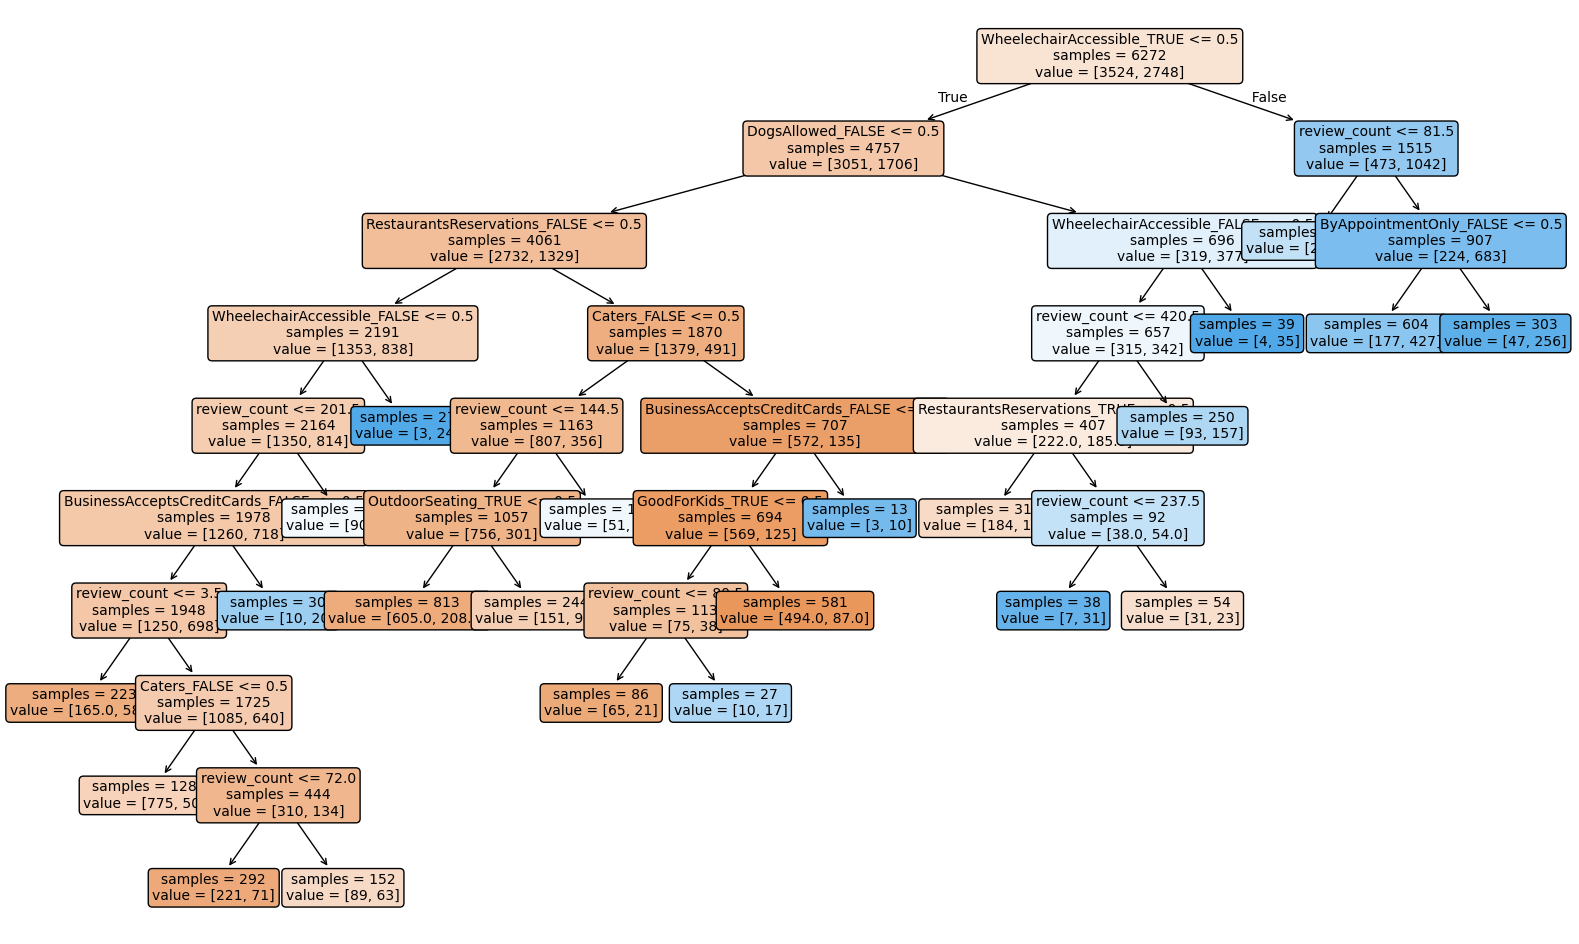

In [30]:


plt.figure(figsize=(20, 12))  # adjust size as you like
plot_tree(
    best_class_tree,                                 
    feature_names=X_train_class.columns,           
    filled=True,                            
    rounded=True,                          
    fontsize=10,                              
    impurity=False                            
)
plt.show()

My approach is doing 5-fold cross-validation on the training set. For each candidate value of ccp_alpha, I trained a DecisionTreeClassifier and computed the mean validation accuracy. I selected the alpha value with the highest mean accuracy, balancing model complexity and overfitting. Then I retrained the decision tree with the chosen best_alpha and visualized it.

### d-v) Comprehensive Model Comparison and Recommendation

We develop a performance table comparing five approaches: baseline (majority class), regression models with thresholding, logistic regression, and classification tree. Metrics include accuracy, true positive rate (TPR/recall), and false positive rate (FPR). We analyze trade-offs between correctly identifying high-rated restaurants (TPR) versus minimizing false alarms (FPR) to recommend the best model for Yelp's business goals.

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n {model_name} Evaluation Results")
    print("Confusion Matrix:\n", cm)

    TN, FP, FN, TP = cm.ravel()
    accuracy = accuracy_score(y_true, y_pred)

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN) 

    print(f"Accuracy: {accuracy:.4f}")
    print(f"TPR (Recall): {TPR:.4f}")
    print(f"FPR: {FPR:.4f}")


    return {"accuracy": accuracy, "TPR": TPR, "FPR": FPR}


Baseline Model

In [ ]:
train_encoded["fourOrAbove"].value_counts()
# 0 is the most frequent class



fourOrAbove
0    3524
1    2748
Name: count, dtype: int64

In [35]:
y_pred_baseline = np.full_like(test_encoded["fourOrAbove"], fill_value=0) 


In [ ]:
baseline_results = evaluate_model(y_test_class, y_pred_baseline, "Baseline_model")
linear_results = evaluate_model(y_test_class, y_pred_linear_class, 'Linear_model')
tree_results = evaluate_model(y_test_class, y_pred_tree_class, "Linear Regression Tree")
logit_results = evaluate_model(y_test_class, y_pred_log, "Logistic Regression")
classification_tree_results = evaluate_model(y_test_class, best_class_tree.predict(X_test_class), "Classification Tree")



 Baseline_model Evaluation Results
Confusion Matrix:
 [[1482    0]
 [1206    0]]
Accuracy: 0.5513
TPR (Recall): 0.0000
FPR: 0.0000

 Linear_model Evaluation Results
Confusion Matrix:
 [[1468   14]
 [1136   70]]
Accuracy: 0.5722
TPR (Recall): 0.0580
FPR: 0.0094

 Linear Regression Tree Evaluation Results
Confusion Matrix:
 [[1474    8]
 [1193   13]]
Accuracy: 0.5532
TPR (Recall): 0.0108
FPR: 0.0054

 Logistic Regression Evaluation Results
Confusion Matrix:
 [[1210  272]
 [ 623  583]]
Accuracy: 0.6670
TPR (Recall): 0.4834
FPR: 0.1835

 Classification Tree Evaluation Results
Confusion Matrix:
 [[1122  360]
 [ 588  618]]
Accuracy: 0.6473
TPR (Recall): 0.5124
FPR: 0.2429


In [45]:
results_df = pd.DataFrame([
    {"Model": "Baseline", **baseline_results},
    {"Model": "Linear Regression Thresholded", **linear_results},
    {"Model": "Regression Tree Thresholded", **tree_results},
    {"Model": "Logistic Regression", **logit_results},
    {"Model": "Classification Tree", **classification_tree_results}
])

results_df


,Model,accuracy,TPR,FPR
0,Baseline,0.551339,0.000000,0.000000
1,Linear Regression Thresholded,0.572173,0.058043,0.009447
2,Regression Tree Thresholded,0.553199,0.010779,0.005398
3,Logistic Regression,0.667039,0.483416,0.183536
4,Classification Tree,0.647321,0.512438,0.242915


### v)

Do the results seem reasonable to you?
How do you judge the performance of the models and the trade-offs between different
models? Which model would you recommend for this problem and why?

Yeah, the results makes sense, the accuracy for linear regression models are slightly higher than the baseline. Futhermore, the classfication models perform even better.

A higher TPR means the model does a better job identifying restaurants that truly deserve high ratings, while a lower FPR helps avoid recommending poorly rated ones. In practice, the ideal balance depends on Yelp’s goal...if promoting great restaurants is the priority, a higher TPR is a better choice. If maintaining user trust is more important, minimizing FPR matters more.

 Overall, I'd recommend the logistic regression model, since it achieves a strong balance.similar TPR to the classification tree but with a noticeably lower FPR

e) (20 points) Suppose that you are a data analytics professional working for Yelp and you have
been tasked with producing a “how to guide” for Las Vegas restaurants, which is supposed
to include tips for actions that restaurants may take to achieve a high star rating. Use the
provided data to construct a list of three such tips. Each of your tips should be justified by
the data, and each justification should be understandable by a restaurant owner who may
not know much about machine learning. This question is purposefully open ended, and you
may consider using modeling techniques and/or visualizations to come up with and justify
your three tips.

## e) Data-Driven Recommendations for Las Vegas Restaurants

Using feature importance from our best-performing classification tree and logistic regression coefficients, we extract actionable insights. We analyze both coefficient magnitudes (which features most influence ratings) and exploratory visualizations (how specific features correlate with ratings) to generate three practical recommendations for restaurants seeking to improve their Yelp ratings.

In [48]:

coef_df = pd.DataFrame({
    "Feature": X_train_log.columns,
    "Coefficient": log_model.coef_[0],
    "Odds_Ratio": np.exp(log_model.coef_[0])
}).sort_values(by="Coefficient", ascending=False)


coef_df.head(10)

,Feature,Coefficient,Odds_Ratio
15,WheelechairAccessible_FALSE,1.842916,6.314924
6,BusinessAcceptsCreditCards_FALSE,1.148763,3.154289
16,WheelechairAccessible_TRUE,1.033022,2.809543
21,DogsAllowed_FALSE,0.635898,1.888717
14,ByAppointmentOnly_TRUE,0.479439,1.615169
13,ByAppointmentOnly_FALSE,0.429811,1.536967
22,DogsAllowed_TRUE,0.381984,1.465189
1,GoodForKids_FALSE,0.190790,1.210206
24,Caters_TRUE,0.157132,1.170151
4,Alcohol_'none',0.151031,1.163033


According to the model, restaurants missing or marked as not wheelchair accessible tended to have higher ratings. This may reflect incomplete data rather than an actual preference

In [ ]:
# importance of features in classification tree

importances = pd.DataFrame({
    "Feature": X_train_class.columns,
    "Importance": best_class_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)
importances

,Feature,Importance
16,WheelechairAccessible_TRUE,0.514437
0,review_count,0.146086
21,DogsAllowed_FALSE,0.112867
19,RestaurantsReservations_FALSE,0.059940
15,WheelechairAccessible_FALSE,0.050578
23,Caters_FALSE,0.035930
6,BusinessAcceptsCreditCards_FALSE,0.029908
13,ByAppointmentOnly_FALSE,0.015863
2,GoodForKids_TRUE,0.013603
18,OutdoorSeating_TRUE,0.012176


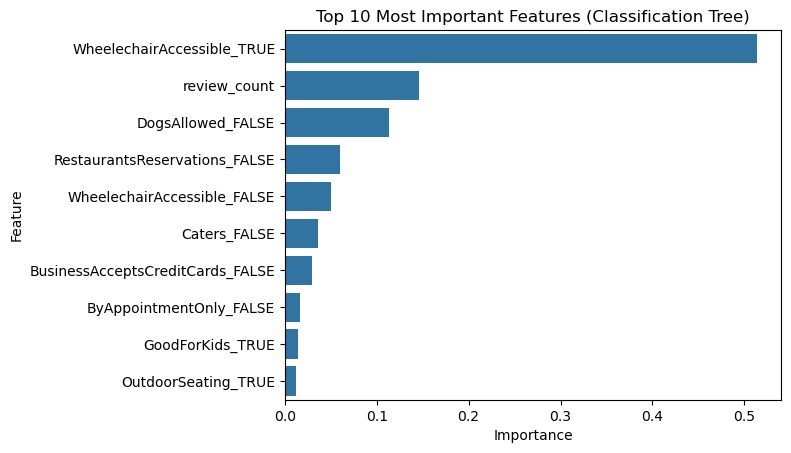

In [52]:
import seaborn as sns
sns.barplot(x="Importance", y="Feature", data=importances.head(10))
plt.title("Top 10 Most Important Features (Classification Tree)")
plt.show()

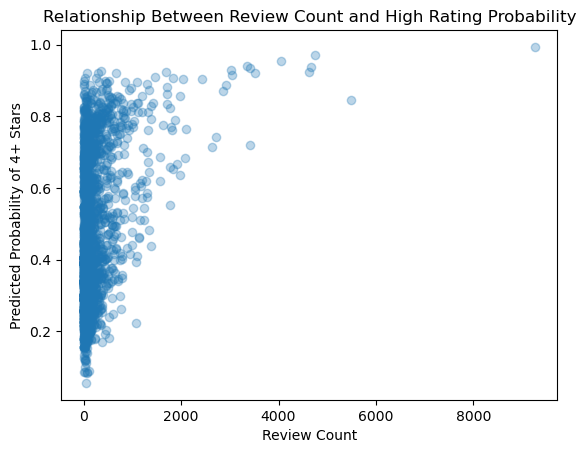

In [53]:
y_prob = log_model.predict_proba(X_test_log)[:, 1]
plt.scatter(test_encoded['review_count'], y_prob, alpha=0.3)
plt.xlabel("Review Count")
plt.ylabel("Predicted Probability of 4+ Stars")
plt.title("Relationship Between Review Count and High Rating Probability")
plt.show()

restaurants with only a few reviews often have very high predicted probabilities of receiving 4 or more stars. Restaurants with both high review counts and high predicted probabilities represent consistently top-rated establishments, suggesting that maintaining quality over time is key to sustaining strong Yelp ratings.

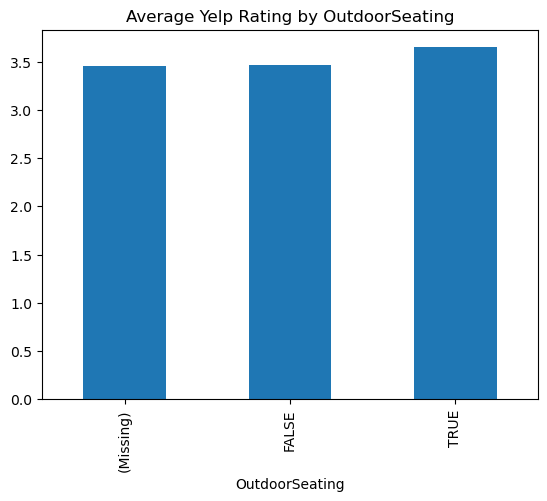

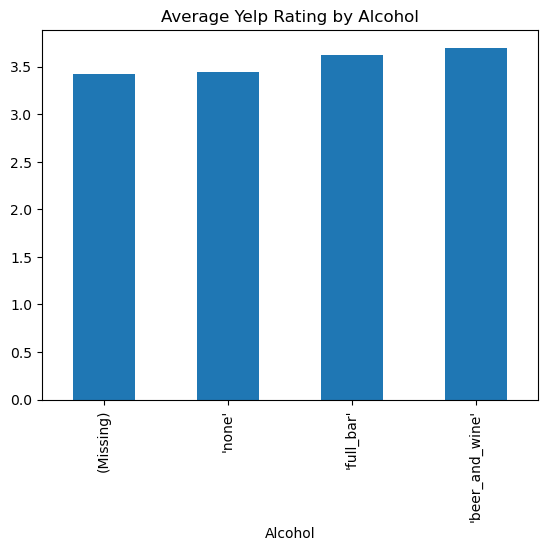

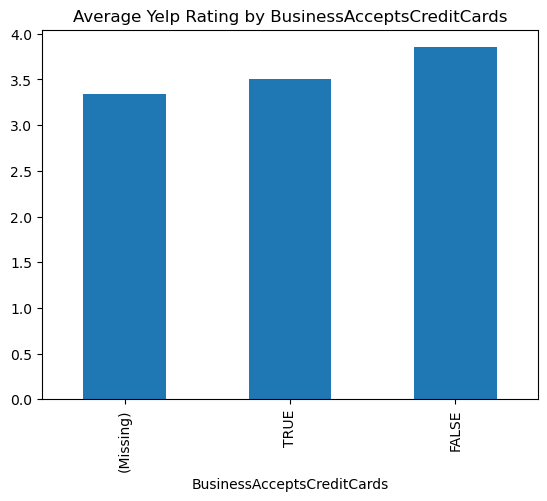

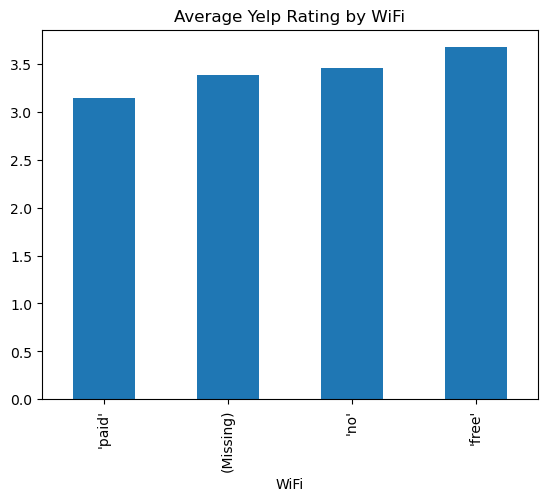

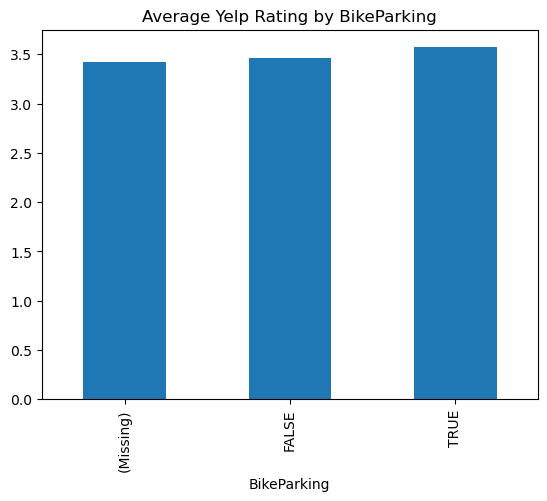

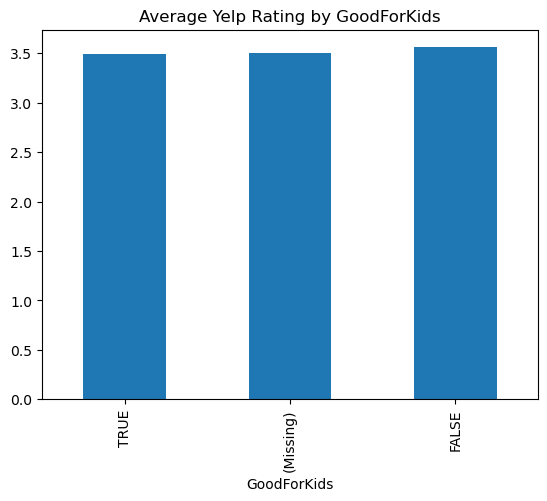

In [56]:
import matplotlib.pyplot as plt

categorical_cols = ['OutdoorSeating', 'Alcohol', 'BusinessAcceptsCreditCards', 
                    'WiFi', 'BikeParking', 'GoodForKids']

for col in categorical_cols:
    train_data.groupby(col)['stars'].mean().sort_values().plot(kind='bar')
    plt.title(f"Average Yelp Rating by {col}")
    plt.xlabel(col)
    plt.show()

## Summary of Findings

This analysis shows that restaurant ratings are shaped most strongly by **business transparency, customer convenience, and review volume**.

### Key Insights

**1. Complete business profiles matter.**  
Features related to wheelchair accessibility, credit card acceptance, dog-friendliness, and reservation availability were among the most important predictors of high ratings. In particular, restaurants with clearly filled-out profile information were much more likely to receive **4+ star ratings** than restaurants with missing information. While the logistic regression results suggest that businesses marked as “not wheelchair accessible” sometimes had higher ratings, this likely reflects **incomplete or inconsistent data** rather than a true customer preference. Overall, the stronger signal is that **profile completeness and transparency build trust**.

**Recommendation:** Restaurants should fully complete their business profiles, including accessibility details, payment options, reservation policies, and pet-related information.

**2. Review count is a major driver of strong ratings.**  
The classification tree identified **number of reviews** as one of the most important features, and the probability plots showed that restaurants with more reviews tended to have a higher predicted probability of receiving **4+ stars**. This suggests that review volume acts as a form of social proof and helps reinforce credibility.

**Recommendation:** Restaurants should encourage satisfied customers to leave reviews, since a higher review count can strengthen reputation and increase the likelihood of maintaining high ratings.

**3. Convenience and inclusivity improve customer satisfaction.**  
Features such as accepting credit cards, offering outdoor seating, providing catering, and allowing dogs all positively influenced ratings. These factors likely improve the overall customer experience by making restaurants more accessible, flexible, and comfortable for a wider range of customers.

**Recommendation:** Restaurants should invest in convenience-focused features, such as easy payment methods, outdoor seating, and inclusive service options, to improve customer experience and ratings.

### Model Performance

For classification, the **logistic regression model** performed best overall because it provided the strongest balance of predictive performance and interpretability. It is the recommended model for **real-time prediction of whether a restaurant will achieve 4+ stars**. The **classification tree** also performed well and offered useful decision rules that are especially valuable for explaining findings to non-technical stakeholders.

For regression, **linear regression** slightly outperformed the regression tree, with **OSR² = 0.147** and **MAE = 0.647**, compared with the regression tree’s **OSR² = 0.124** and **MAE = 0.670**. However, both regression models explained only a limited share of the variation in star ratings, suggesting that restaurant ratings are also influenced by more complex or unobserved factors.

### Final Takeaway

Overall, the results suggest that restaurants can improve their ratings not only through food quality, but also by focusing on **clear profile information, customer convenience, inclusivity, and strong review generation**. From a modeling perspective, **logistic regression** is the most practical deployment choice, while the **classification tree** is useful for interpretation and communication.